In [402]:
import psycopg2 as pg
import pandas as pd
import math
import numpy as np
import pandas.io.sql as psql

In [372]:
connection = pg.connect("host=localhost dbname=Simulacred user=postgres password=12345678")

In [311]:
connection.close()

In [373]:
serie_pd = psql.read_sql('SELECT * FROM jpcosta.calculo_pd', connection)

In [380]:
serie_pd_2 = psql.read_sql('SELECT * FROM jpcosta.calculo_pd_2', connection)

In [386]:
df1 = serie_pd_2[['ref', 'porte', 'modalidade', 'qtd', 'qtd_inad']].groupby(['ref', 'porte', 'modalidade']).sum().reset_index()

pd = df1['qtd_inad']/df1['qtd']

df1['pd'] = pd
df1

,ref,porte,modalidade,qtd,qtd_inad,pd
0,0,1,1,174,21,0.1206896551724138
1,0,1,2,967,56,0.057911065149948295
2,0,1,3,66,1,0.015151515151515152
3,0,1,4,21,0,0.0
4,0,2,1,63,6,0.09523809523809523
...,...,...,...,...,...,...
2251,93,5,4,281,10,0.03558718861209965
2252,93,6,1,493,40,0.08113590263691683
2253,93,6,2,2682,135,0.050335570469798654
2254,93,6,3,149,6,0.040268456375838924


In [190]:
probd.columns

Index(['ref', 'porte', 'modalidade', 'pd'], dtype='object')

In [374]:
probd = serie_pd[['ref', 'porte', 'modalidade', 'pd']]

In [375]:
pd_model = probd[(probd['ref'] > 0) & ((probd['ref'] < 48))].drop('ref', axis=1).groupby(['porte', 'modalidade']).mean().reset_index()
pd_model

,porte,modalidade,pd
0,1,1,0.20434544952723582
1,1,2,0.1376708692589457
2,1,3,0.10355575881584488
3,1,4,0.06293166196415345
4,2,1,0.16559432283245606
5,2,2,0.10554935104276306
6,2,3,0.07228007984606388
7,2,4,0.02892996280999309
8,3,1,0.14034102489771547
9,3,2,0.08601895564877157


In [376]:
pd_monit = probd[probd['ref'].between(72, 84)].drop('ref', axis=1).groupby(['porte', 'modalidade']).mean().reset_index()
pd_monit = pd_monit.rename(columns={'pd': 'pd_monit'})
pd_monit

,porte,modalidade,pd_monit
0,1,1,0.32006694295952987
1,1,2,0.24487533127169464
2,1,3,0.2112061680893573
3,1,4,0.1689378260083814
4,2,1,0.28048172311964853
5,2,2,0.20575027263036152
6,2,3,0.16122825246782796
7,2,4,0.12410805232781041
8,3,1,0.24707576664861863
9,3,2,0.16738426369824905


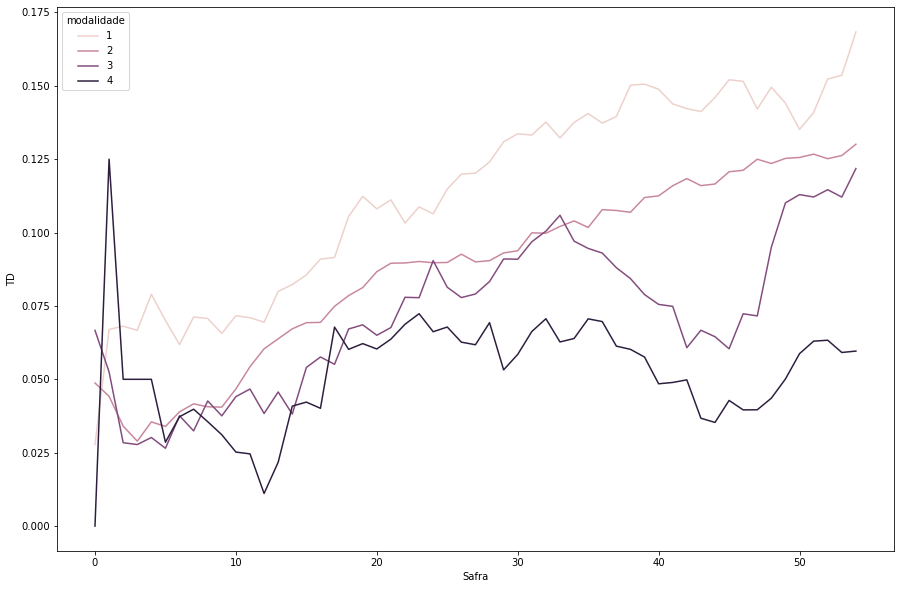

In [257]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame
df  = probd.groupby(['modalidade', 'ref']).mean()

# this is to plot the kde
sns.lineplot(data=df, x='ref', y = 'pd',  hue='modalidade')

# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

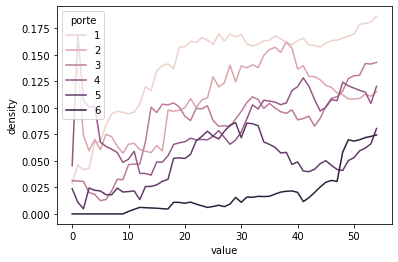

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# data to create an example data frame
df  = probd.groupby(['porte', 'ref']).mean()

# this is to plot the kde
sns.lineplot(data=df, x='ref', y = 'pd',  hue='porte')

# beautifying the labels
plt.xlabel('value')
plt.ylabel('density')
plt.show()

In [259]:
#probd[(probd.modalidade == 2) & (probd.porte == 6)][['ref', 'pd']].plot(x = 'ref')

In [377]:
lgd_i = psql.read_sql('SELECT * FROM jpcosta.calculo_lgd60', connection)

lgd = lgd_i[lgd_i.ref > 0].drop('ref', axis=1).groupby(['porte', 'modalidade']).mean('lgd').reset_index()
lgd

,porte,modalidade,lgd
0,1,1,0.5996499848959366
1,1,2,0.5553973730761625
2,1,3,0.45845902487603907
3,1,4,0.38362877790503636
4,2,1,0.6074670070036838
5,2,2,0.5231382876388134
6,2,3,0.557499526448972
7,2,4,0.46908343982122763
8,3,1,0.581593063898711
9,3,2,0.5394605685285092


In [288]:
ecl = pd_model.merge(lgd, on=['porte', 'modalidade'], how='left').fillna(0.500)
ecl['ecl'] = ecl['pd'] * ecl['lgd']
ecl = ecl.merge(pd_monit, on=['porte', 'modalidade'], how='left')
ecl['ecl2'] = ecl['pd_monit'] * ecl['lgd']

ecl

,porte,modalidade,pd,lgd,ecl,pd_monit,ecl2
0,1,1,0.20228323587747518,0.6068350768875376,0.12275256299676755,0.5001324121672908,0.30349789079148753
1,1,2,0.13531967124979782,0.5468734083817011,0.07400272983746822,0.4001184146054176,0.2188141211515473
2,1,3,0.1056317559020816,0.5221498537492251,0.055155605895545745,0.34941492214460396,0.1824469504956018
3,1,4,0.06277791725605902,0.3457112097724612,0.021703029721587636,0.26799904666605723,0.09265027464078894
4,2,1,0.16425786061281433,0.6095489560948786,0.10012320746691905,0.4605772325655702,0.28074437131141144
5,2,2,0.10285964684476157,0.5433313232991034,0.05588686803424275,0.3351204559116322,0.18208144077506597
6,2,3,0.09647475325856324,0.48309507493742565,0.04660647815501526,0.2908518778776567,0.14050910973899755
7,2,4,0.06440619095387497,0.42886655739328927,0.02762166138920317,0.20994791392619752,0.09003963907743094
8,3,1,0.13992878619390167,0.6203118072064951,0.08679947824415041,0.41840790326061394,0.2595433626210718
9,3,2,0.08559992385830326,0.5563133390032405,0.04762037946003584,0.2956635015136379,0.16448154974844156


In [289]:
dict_prov = {  'AA': 0.00,
               'A' : 0.005,
               'B':  0.01,
               'C':  0.03,
               'D':  0.10,
               'E':  0.30,
               'F':  0.50,
               'G':  0.70,
               'H':  1.00,
               'HH': 0.00}          

In [378]:
pd.options.display.float_format = '{:2}'.format

agg = psql.read_sql('SELECT * FROM jpcosta.perda_obs', connection)

agg['prov'] = agg['nivel_risco'].map(dict_prov)*agg['saldo']

In [314]:
agg = agg.merge(ecl, how='left', on=['porte', 'modalidade'])

In [315]:
prob = []

for i in range(len(agg)):
    if agg.estagio[i] == 1:
        prob.append(agg.pd[i])
    elif agg.estagio[i] == 2:
        
        b = (0.11852 - 0.05478*math.log(max(0.003, agg.pd[i])))**2
        m = (1 + (3 - 2.5) * b)/(1 - (1.5) * b)
        
        prob.append(agg.pd[i]*m)
        
    else:
        prob.append(1.00)

agg['pd'] = prob

agg['ecl'] = agg['pd'] * agg['lgd'] * agg['saldo']
agg['ecl2'] = agg['pd_monit'] * agg['lgd'] * agg['saldo']

In [316]:
hst = agg[agg['nivel_risco'] != 'HH'][['ref', 'saldo', 'saldo_inad', 'prov', 'ecl', 'ecl2', 'perda_att']].groupby(['ref']).sum(['prov', 'saldo', 'ecl', 'perda_att'])

In [317]:
hst['iprov'] = hst['prov']/hst['saldo']
hst['inad90'] = hst['saldo_inad']/hst['saldo']
hst['iPE'] = hst['ecl']/hst['saldo']
hst['perda_obs'] = hst['perda_att']/hst['saldo']
hst['dif'] = hst['iPE'] - hst['iprov']

In [318]:
hst[['iPE','iprov','inad90', 'perda_obs', 'dif']]

,iPE,iprov,inad90,perda_obs,dif
ref,,,,,
0,0.04087365689924993,0.014226978547988663,0.0,0.018378876013433385,0.02664667835126127
1,0.039331812140492604,0.0150502015898551,0.0,0.01911587968259951,0.024281610550637503
2,0.039664561791325104,0.0161088970097559,0.0,0.01854787204455008,0.023555664781569202
3,0.039799300283215454,0.017081115753677736,0.0,0.02143689930582831,0.022718184529537718
4,0.03988261865412973,0.017953330536673737,0.00023060277709098122,0.021590068716707926,0.021929288117455994
...,...,...,...,...,...
113,0.04359675525445053,0.05963461817322508,0.030272919052576678,0.0,-0.01603786291877455
114,0.0435886805846023,0.05988084224052656,0.030271122832490838,0.0,-0.01629216165592426
115,0.04350368685311113,0.05983852854459573,0.031100760374894062,0.0,-0.0163348416914846


In [403]:
#pd.options.display.float_format = '{:2}'.format

agg = psql.read_sql('SELECT * FROM jpcosta.perda_obs', connection)

agg['prov'] = agg['nivel_risco'].map(dict_prov)*agg['saldo']

In [404]:
agg

,ref,nivel_risco,porte,modalidade,estagio,qtd,saldo,saldo_inad,perda_att,prov
0,0,A,1,1,1,1,3533.16,0.0,0.0,17.6658
1,0,A,1,2,1,2,4282.42,0.0,0.0,21.412100000000002
2,0,A,1,3,1,1,29133.97,0.0,0.0,145.66985
3,0,A,2,3,1,1,38057.07,0.0,0.0,190.28535
4,0,A,3,1,1,1,6524.94,0.0,0.0,32.6247
...,...,...,...,...,...,...,...,...,...,...
23439,107,HH,5,4,3,30,8398799.54,0.0,0.0,0.0
23440,107,HH,6,1,3,367,3776502.62,0.0,0.0,0.0
23441,107,HH,6,2,3,1174,5263690.25,0.0,0.0,0.0
23442,107,HH,6,3,3,53,939238.85,0.0,0.0,0.0


In [389]:
agg2 = psql.read_sql('SELECT * FROM jpcosta.perda_obs_atr', connection)

In [405]:
df2 = agg2[['ref', 'nivel_risco', 'porte', 'qtd','modalidade', 'estagio', 'saldo', 'saldo_inad', 'perda_att']]\
        .groupby(['ref', 'nivel_risco', 'porte', 'modalidade', 'estagio']).sum().reset_index()

df2['prov'] = df2['nivel_risco'].map(dict_prov)*df2['saldo']

df2

,ref,nivel_risco,porte,modalidade,estagio,qtd,saldo,saldo_inad,perda_att,prov
0,0,A,1,1,1,1,3533.16,0.0,0.0,17.6658
1,0,A,1,2,1,2,4282.42,0.0,0.0,21.412100000000002
2,0,A,1,3,1,1,29133.97,0.0,0.0,145.66985
3,0,A,2,3,1,1,38057.07,0.0,0.0,190.28535
4,0,A,3,1,1,1,6524.94,0.0,0.0,32.6247
...,...,...,...,...,...,...,...,...,...,...
23374,107,HH,5,4,3,8,2204722.61,0.0,0.0,0.0
23375,107,HH,6,1,3,79,916973.96,0.0,0.0,0.0
23376,107,HH,6,2,3,263,889328.84,0.0,0.0,0.0
23377,107,HH,6,3,3,17,154258.11,0.0,0.0,0.0


In [320]:
n = agg.ref.max() - 1

In [321]:
n

116

<AxesSubplot:>

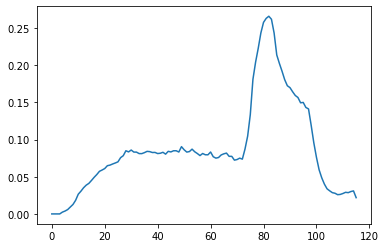

In [282]:
teste = agg[(agg['porte']==1) & (agg['modalidade']==1)].groupby(['ref', 'modalidade']).sum().reset_index()
teste['tx'] = teste['saldo_inad']/teste['saldo']

teste['tx'].plot()

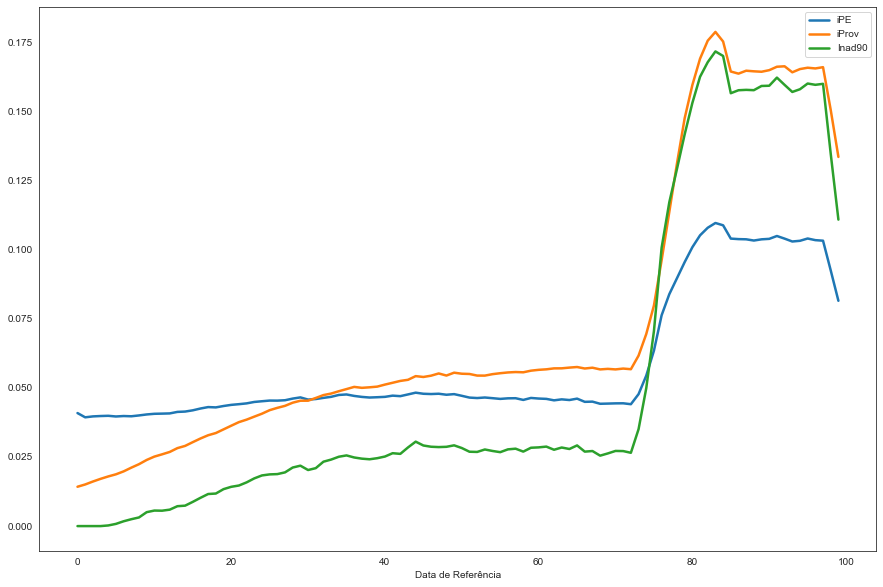

In [370]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.color_palette("ch:s=.25,rot=-.25", as_cmap=True)
#sns.set_style()
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame
df  = hst[['iPE','iprov','inad90', 'perda_obs']]#[60:n-82]

# this is to plot the kde
sns.lineplot(data=df[:100], x='ref', y = 'iPE', label='iPE', linewidth=2.5)
sns.lineplot(data=df[:100], x='ref', y = 'iprov', label='iProv', linewidth=2.5)
sns.lineplot(data=df[:100], x='ref', y = 'inad90', label='Inad90', linewidth=2.5)
#sns.lineplot(data=df[:50], x='ref', y = 'perda_obs', label='PO')

# beautifying the labels
plt.xlabel('Data de Referência')
plt.ylabel('')
plt.show()

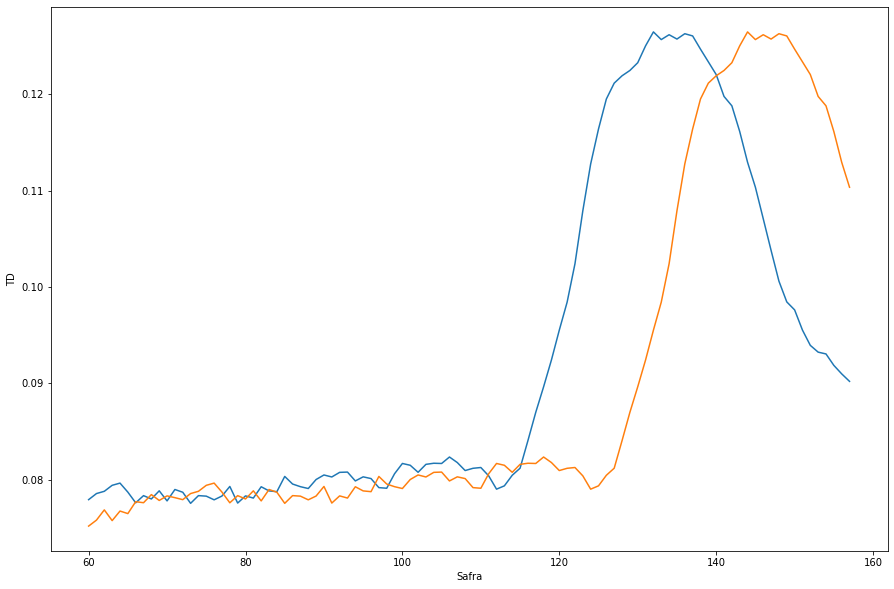

In [405]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame
df1  = probd.groupby(['ref']).mean().reset_index()
df1['ref_r'] = df1['ref'] + 12

# this is to plot the kde
sns.lineplot(data=df1[df1['ref'].between(60, n-82, inclusive='both')], x='ref', y = 'pd')
sns.lineplot(data=df1[df1['ref_r'].between(60, n-82, inclusive='both')], x='ref_r', y = 'pd')

# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

In [406]:
df1['varpd'] = ((df1['pd']/df1['pd'].shift(1))-1).rolling(window=12).mean()
df['varnpl'] = ((df['inad90']/df['inad90'].shift(1))-1).rolling(window=12).mean()

In [17]:
inad = agg[(agg.nivel_risco != 'HH') & (agg.ref==n)][['porte', 'modalidade','saldo']].groupby(['porte', 'modalidade']).sum()
inad['inad'] = inad['saldo_inad']/inad['saldo']

inad

KeyError: 'saldo_inad'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame
#df1  = probd.groupby(['ref']).mean().reset_index()
#df1['ref_r'] = df1['ref'] + 12

# this is to plot the kde
sns.lineplot(data=df1[df1['ref_r'].between(60, n-82, inclusive='both')], x='ref_r', y = 'varpd', label = '%TD')
sns.lineplot(data=df, x='ref', y = 'varnpl', label = '%NPL')

# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame

# this is to plot the kde
sns.lineplot(data=hst[36:145], x='ref', y = 'ecl', color='black')
sns.lineplot(data=hst[144:n-36], x='ref', y = 'ecl', linestyle='dotted', color='grey')
sns.lineplot(data=hst[36:157], x='ref', y = 'ecl2', linestyle='dotted', color='grey')
sns.lineplot(data=hst[156:n-36], x='ref', y = 'ecl2', color='black')
#sns.lineplot(data=hst[36:157], x='ref', y = 'perda_att', color='black')

ax.axvline(144, ls='--', c='grey')
ax.axvline(156, ls='--', c='grey')
ax.axvline(121, ls='--', c='grey')

# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

In [641]:
probd['td'] = probd.groupby(['porte','modalidade'])['pd'].shift(12)

probd['PD_12'] = probd.groupby(['porte','modalidade']).rolling(window=12)['td'].mean().reset_index()['td']
probd['PD_24'] = probd.groupby(['porte','modalidade']).rolling(window=24)['td'].mean().reset_index()['td']
probd['PD_36'] = probd.groupby(['porte','modalidade']).rolling(window=36)['td'].mean().reset_index()['td']
probd['PD_48'] = probd.groupby(['porte','modalidade']).rolling(window=48)['td'].mean().reset_index()['td']

<ipython-input-641-0bcf1567ad1e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  probd['td'] = probd.groupby(['porte','modalidade'])['pd'].shift(12)
<ipython-input-641-0bcf1567ad1e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  probd['PD_12'] = probd.groupby(['porte','modalidade']).rolling(window=12)['td'].mean().reset_index()['td']
<ipython-input-641-0bcf1567ad1e>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

In [642]:
probd = probd.merge(pd_monit[['porte', 'modalidade', 'pd_monit']], how='left', on=['modalidade', 'porte'])
probd = probd.merge(pd_model[['porte', 'modalidade', 'pd']].rename(columns={'pd':'pd_model'}), how='left', on=['modalidade', 'porte'])

In [643]:
probd[(probd.ref.between(142, 158)) & (probd.modalidade == agg.modalidade[i]) & (probd.porte == agg.porte[i])]

,ref,porte,modalidade,pd,td,PD_12,PD_24,PD_36,PD_48,pd_monit,pd_model
598,142,1,3,0.12087057909055578,0.12427856868026164,0.11976498321959927,0.10104899044040438,0.09691764236405737,0.09621872880991454,0.12429293085514598,0.09177793290550827
599,143,1,3,0.11812865497076024,0.1255294570658452,0.12156570278919626,0.1028085075637246,0.09791716887449091,0.09696742437068871,0.12429293085514598,0.09177793290550827
600,144,1,3,0.1168679392286716,0.12422839506172839,0.12320970392865253,0.10465006235666828,0.0988272423989232,0.09765941286262908,0.12429293085514598,0.09177793290550827
601,145,1,3,0.11189634864546526,0.12480680061823803,0.12433011012514354,0.10665019055672352,0.09985058438952459,0.09832434812015735,0.12429293085514598,0.09177793290550827
602,146,1,3,0.10758998435054773,0.12052877138413685,0.12477082105380159,0.10858879250271436,0.10070315261718316,0.0988384071727827,0.12429293085514598,0.09177793290550827
603,147,1,3,0.09897879025923016,0.12475633528265107,0.12515206516938154,0.11073270359216637,0.10168372712959195,0.09941214484153343,0.12429293085514598,0.09177793290550827
604,148,1,3,0.09490196078431372,0.12886799843321584,0.12565161954417223,0.11299083580812569,0.10273134247068555,0.1001462377454602,0.12429293085514598,0.09177793290550827
605,149,1,3,0.09115699259836385,0.12915851272015655,0.1259507419370128,0.11522478693745818,0.10380161739337661,0.10086878612554283,0.12429293085514598,0.09177793290550827
606,150,1,3,0.09253499222395023,0.12915851272015655,0.12604071651919332,0.11716980225113377,0.1049024372019714,0.1015925268021159,0.12429293085514598,0.09177793290550827
607,151,1,3,0.09218203033838973,0.12519561815336464,0.1257494858593772,0.11882626079807314,0.10592561464927033,0.10223580672576554,0.12429293085514598,0.09177793290550827


In [476]:
lgd[(lgd.porte == 2) & (lgd.modalidade == 3)]

,porte,modalidade,lgd
6,2,3,0.1790739918321821


In [495]:
pd.set_option('display.max_columns', None)
a = agg2[(agg2['porte']==2) & (agg2['modalidade']==3) & (agg2['ref']==144) & (agg2['nivel_risco'] != 'HH')]

a[['estagio', 'saldo', 'prov', 'ecl', 'ecl2', 'ecl3', 'ecl4', 'ecl5', 'ecl6', 'ecl7']].groupby('estagio').sum()

,saldo,prov,ecl,ecl2,ecl3,ecl4,ecl5,ecl6,ecl7
estagio,,,,,,,,,
1,9359799.16,280793.97479999997,133719.0748788519,195298.03606905756,224372.571604442,199993.85752335508,164935.8290453622,155438.7680207783,151361.08190888507
2,732070.7,39143.704300000005,11992.662784711272,15275.110878949694,19540.799174057654,18659.604381050944,14610.478832118148,13769.202501377087,13407.98961654384
3,247481.49,128890.973,44317.49831887625,5163.855349268425,44317.49831887625,44317.49831887625,44317.49831887625,44317.49831887625,44317.49831887625


In [644]:
prob, prob0, prob1, prob2, prob3, prob4, prob5 = [], [], [], [], [], [], []

agg2 = agg[agg.ref <= max(probd.ref)]

for i in range(len(agg2)):
    p  = probd[(probd.ref == agg2.ref[i]) & (probd.modalidade == agg2.modalidade[i]) & (probd.porte == agg2.porte[i])].pd_model.values[0]
    p0 = probd[(probd.ref == agg2.ref[i]) & (probd.modalidade == agg2.modalidade[i]) & (probd.porte == agg2.porte[i])].td.values[0]
    p1 = probd[(probd.ref == agg2.ref[i]) & (probd.modalidade == agg2.modalidade[i]) & (probd.porte == agg2.porte[i])].PD_12.values[0]
    p2 = probd[(probd.ref == agg2.ref[i]) & (probd.modalidade == agg2.modalidade[i]) & (probd.porte == agg2.porte[i])].PD_24.values[0]
    p3 = probd[(probd.ref == agg2.ref[i]) & (probd.modalidade == agg2.modalidade[i]) & (probd.porte == agg2.porte[i])].PD_36.values[0]
    p4 = probd[(probd.ref == agg2.ref[i]) & (probd.modalidade == agg2.modalidade[i]) & (probd.porte == agg2.porte[i])].PD_48.values[0]
    p5 = probd[(probd.ref == agg2.ref[i]) & (probd.modalidade == agg2.modalidade[i]) & (probd.porte == agg2.porte[i])].pd_monit.values[0]
  
    if agg.estagio[i] == 1:
        prob.append(p)
        prob0.append(p0)
        prob1.append(p1)
        prob2.append(p2)
        prob3.append(p3)
        prob4.append(p4)
        prob5.append(p5)       
        
    elif agg.estagio[i] == 2:
        
        b = (0.11852 - 0.05478*math.log(max(0.003, p)))**2          
        b0 = (0.11852 - 0.05478*math.log(max(0.003, p0)))**2     
        b1 = (0.11852 - 0.05478*math.log(max(0.003, p1)))**2
        b2 = (0.11852 - 0.05478*math.log(max(0.003, p2)))**2
        b3 = (0.11852 - 0.05478*math.log(max(0.003, p3)))**2
        b4 = (0.11852 - 0.05478*math.log(max(0.003, p4)))**2
        b5 = (0.11852 - 0.05478*math.log(max(0.003, p5)))**2
        
        m = (1 + (3 - 2.5) * b)/(1 - (1.5) * b)         
        m0 = (1 + (3 - 2.5) * b0)/(1 - (1.5) * b0)      
        m1 = (1 + (3 - 2.5) * b1)/(1 - (1.5) * b1)
        m2 = (1 + (3 - 2.5) * b2)/(1 - (1.5) * b2)
        m3 = (1 + (3 - 2.5) * b3)/(1 - (1.5) * b3)
        m4 = (1 + (3 - 2.5) * b4)/(1 - (1.5) * b4)
        m5 = (1 + (3 - 2.5) * b5)/(1 - (1.5) * b5)
        
        prob.append(p*m)        
        prob0.append(p0*m0)        
        prob1.append(p1*m1)
        prob2.append(p2*m2)
        prob3.append(p3*m3)
        prob4.append(p4*m4)
        prob5.append(p5*m5)
        
    else:
        
        prob.append(1.00)       
        prob0.append(1.00)
        prob1.append(1.00)
        prob2.append(1.00)
        prob3.append(1.00)  
        prob4.append(1.00)
        prob5.append(1.00)

agg2['pd'] = prob
agg2['td'] = prob0
agg2['pd_12'] = prob1
agg2['pd_24'] = prob2
agg2['pd_36'] = prob3
agg2['pd_48'] = prob4
agg2['pd_mnt'] = prob5

agg2['ecl'] = agg2['pd'] * agg2['lgd'] * agg2['saldo']
agg2['ecl2'] = agg2['pd_mnt'] * agg2['lgd'] * agg2['saldo']
agg2['ecl3'] = agg2['td'] * agg2['lgd'] * agg2['saldo']
agg2['ecl4'] = agg2['pd_12'] * agg2['lgd'] * agg2['saldo']
agg2['ecl5'] = agg2['pd_24'] * agg2['lgd'] * agg2['saldo']
agg2['ecl6'] = agg2['pd_36'] * agg2['lgd'] * agg2['saldo']
agg2['ecl7'] = agg2['pd_48'] * agg2['lgd'] * agg2['saldo']

<ipython-input-644-d43ea94b657d>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg2['pd'] = prob
<ipython-input-644-d43ea94b657d>:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg2['td'] = prob0
<ipython-input-644-d43ea94b657d>:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vie

In [645]:
hst2 = agg2[agg2['nivel_risco'] != 'HH'][['ref', 'saldo', 'saldo_inad', 'prov', 'ecl', 'ecl2','ecl3', 'ecl4','ecl5', 'ecl6', 'ecl7', 'perda_att']].groupby(['ref']).sum(['prov', 'saldo', 'ecl', 'perda_att'])

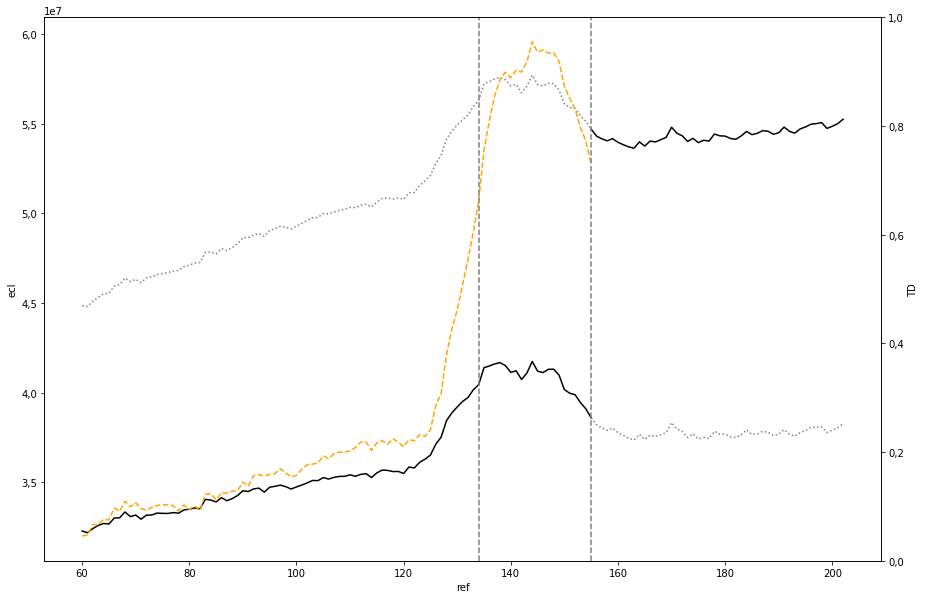

In [655]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax1 = plt.subplots(figsize=(15,10))
# data to create an example data frame
ax2 = ax1.twinx() 
# this is to plot the kde
sns.lineplot(data=hst2[60:156], x='ref', y = 'ecl', color='black', ax = ax1)
sns.lineplot(data=hst2[155:n-36], x='ref', y = 'ecl', linestyle='dotted', color='grey', ax = ax1)
sns.lineplot(data=hst2[60:156], x='ref', y = 'ecl2', linestyle='dotted', color='grey', ax = ax1)
sns.lineplot(data=hst2[155:n-36], x='ref', y = 'ecl2', color='black', ax = ax1)
#sns.lineplot(data=hst2[60:n-36], x='ref', y = 'prov', color='black', ax = ax1)
#sns.lineplot(data=df1[60:148][df1['ref_r'].between(60, 148, inclusive='both')], x='ref_r', y = 'pd', ax = ax2)

sns.lineplot(data=hst2[60:156], x='ref', y = 'ecl3', linestyle='dashed', color='orange', ax = ax1)
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl4', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl5', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl6', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'ecl7', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'prov', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'perda_att', linestyle='dashed')


ax1.axvline(134, ls='--', c='grey')
ax1.axvline(155, ls='--', c='grey')


# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

In [677]:
choque = data=hst2[115:136][['prov','ecl','ecl3', 'ecl4']]
choque['prov2'] = choque['prov'].map('R$ {:,.2f}'.format)
choque['ecl2']  = choque['ecl'].map('R$ {:,.2f}'.format) 
choque['ecl32'] = choque['ecl3'].map('R$ {:,.2f}'.format)
choque['ecl42'] = choque['ecl4'].map('R$ {:,.2f}'.format)

choque['var_prov'] = (choque['prov'] - choque[choque.index == 115].prov.values[0])/choque[choque.index == 115].prov.values[0]
choque['var_ecl'] = (choque['ecl'] - choque[choque.index == 115].ecl.values[0])/choque[choque.index == 115].ecl.values[0]
choque['var_ecl3'] = (choque['ecl3'] - choque[choque.index == 115].ecl3.values[0])/choque[choque.index == 115].ecl3.values[0]
choque['var_ecl4'] = (choque['ecl4'] - choque[choque.index == 115].ecl4.values[0])/choque[choque.index == 115].ecl4.values[0]

choque[['var_prov','var_ecl','var_ecl3', 'var_ecl4']]

,var_prov,var_ecl,var_ecl3,var_ecl4
ref,,,,
115,0.0,0.0,0.0,0.0
116,0.002280933675340861,0.004435133966398959,0.0031220173889123584,0.005869316085093684
117,0.007850090454830127,0.0039816851623705705,-0.0018492852559452073,0.005953480810561061
118,0.0019839786659302952,0.0020805100536971707,0.006227535355387509,0.005523703531678218
119,0.00010154792591169926,0.002304670903683383,0.0011783556243212903,0.006472763158495862
120,0.002941741664652937,-0.0009463428862465828,-0.006000401381372924,0.0036040134261442766
121,0.010877526634864488,0.009252536345699629,0.004890596738735979,0.013795521874374623
122,0.060815544813942496,0.0078085840712782935,0.0030596783918289167,0.01289995923623248
123,0.09768909377019418,0.01674590964403309,0.012431172009873709,0.021424173065676927


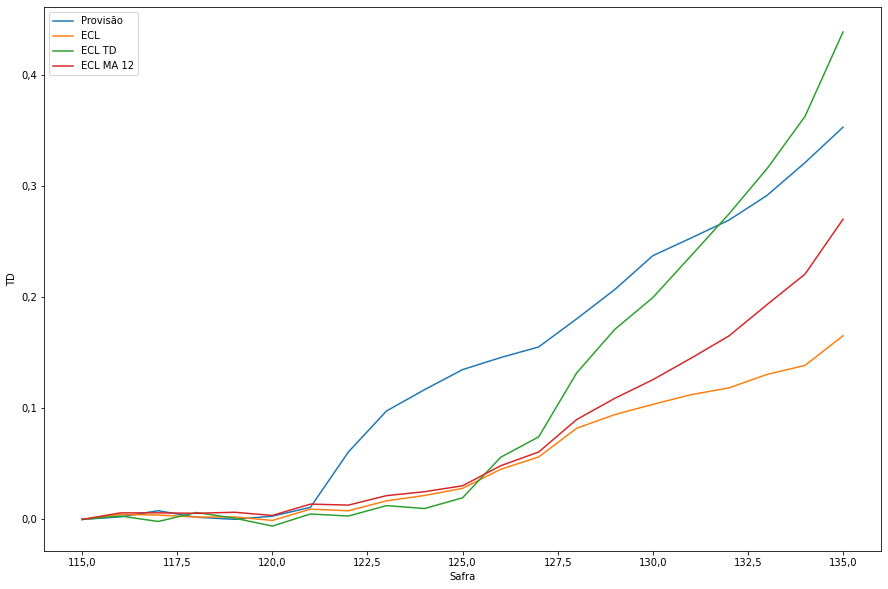

In [680]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame

# this is to plot the kde
sns.lineplot(data=choque, x='ref', y = 'var_prov', label='Provisão')
sns.lineplot(data=choque, x='ref', y = 'var_ecl', label='ECL')
sns.lineplot(data=choque, x='ref', y = 'var_ecl3', label='ECL TD')
sns.lineplot(data=choque, x='ref', y = 'var_ecl4', label='ECL MA 12')



#ax1.axvline(134, ls='--', c='grey')
#ax1.axvline(155, ls='--', c='grey')


# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

In [647]:
a = hst2[hst2.index==148][['saldo', 'ecl', 'ecl2']]

a['saldo'] = a['saldo'].map('R$ {:,.2f}'.format)
a['ecl'] = a['ecl'].map('R$ {:,.2f}'.format)
a['ecl2'] = a['ecl2'].map('R$ {:,.2f}'.format)

a

,saldo,ecl,ecl2
ref,,,
148,"R$ 958,236,139.25","R$ 41,304,670.86","R$ 57,246,016.77"


NameError: name 'hst2' is not defined

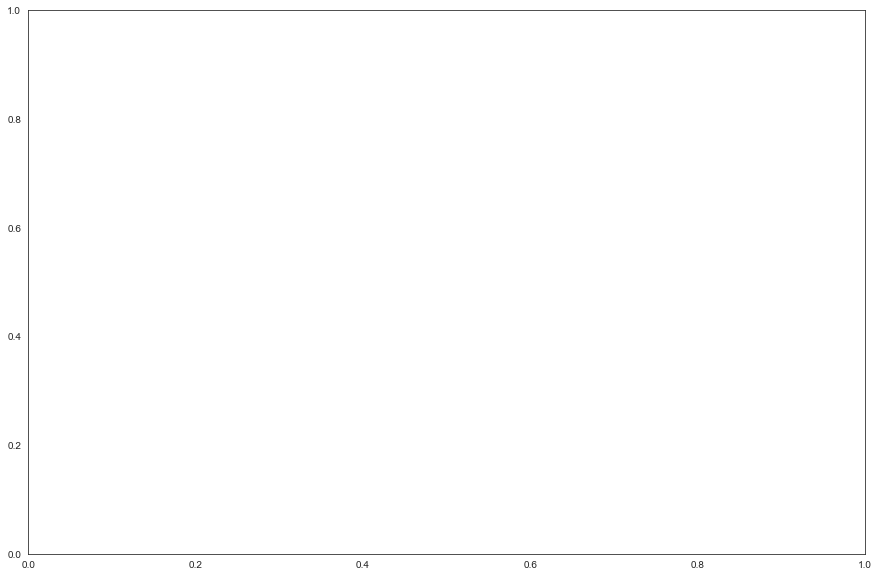

In [369]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame

# this is to plot the kde
sns.lineplot(data=hst2[60:n-36], x='ref', y = 'ecl', linestyle='dotted', color='grey')
sns.lineplot(data=hst2[60:n-36], x='ref', y = 'ecl2', linestyle='dotted', color='grey')
sns.lineplot(data=hst2[60:], x='ref', y = 'ecl3', linestyle='dashed', color='grey')
sns.lineplot(data=hst2[60:], x='ref', y = 'ecl4', linestyle='dashed', color='grey')
sns.lineplot(data=hst2[60:], x='ref', y = 'ecl5', linestyle='dashed', color='grey')
sns.lineplot(data=hst2[60:], x='ref', y = 'ecl6', linestyle='dashed', color='grey')
sns.lineplot(data=hst2[60:], x='ref', y = 'ecl7', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'prov', linestyle='dashed', color='grey')
#sns.lineplot(data=hst2[60:], x='ref', y = 'perda_att', linestyle='dashed')


ax.axvline(144, ls='--', c='grey')
ax.axvline(156, ls='--', c='grey')
ax.axvline(121, ls='--', c='grey')

# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

In [ ]:
hst2['iprov'] = hst2['prov']/hst['saldo']
hst2['inad90'] = hst2['saldo_inad']/hst['saldo']
hst2['iPE'] = hst2['ecl']/hst['saldo']
hst2['perda_obs'] = hst2['perda_att']/hst['saldo']
hst2['dif'] = hst2['iPE'] - hst2['iprov']

In [329]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame

# this is to plot the kde
sns.lineplot(data=hst[36:145], x='ref', y = 'ecl', color='black')
sns.lineplot(data=hst[144:n-36], x='ref', y = 'ecl', linestyle='dotted', color='grey')
sns.lineplot(data=hst[36:157], x='ref', y = 'ecl2', linestyle='dotted', color='grey')
sns.lineplot(data=hst[156:n-36], x='ref', y = 'ecl2', color='black')
#sns.lineplot(data=hst[36:157], x='ref', y = 'perda_att', color='black')

ax.axvline(144, ls='--', c='grey')
ax.axvline(156, ls='--', c='grey')
ax.axvline(121, ls='--', c='grey')

# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

,ref,nivel_risco,porte,modalidade,estagio,saldo,saldo_inad,perda_att,prov,pd,lgd,ecl,pd_monit,ecl2,pd_mm,ecl3
0,0,A,5,2,1,27782.76,0.0,0.0,138.9138,0.07061777298115769,0.3519431588158705,690.4972168028946,0.12211670735148233,1194.051341350439,0.09823460147305324,960.5332488888237
1,0,A,6,1,1,220270.09,0.0,0.0,1101.35045,0.08168511621276749,0.45546136161917833,8195.019676189278,0.11425367466959453,11462.444511377327,0.07922791948653314,7948.50260608672
2,0,A,6,2,1,1639248.68,0.0,14183.009470629782,8196.2434,0.0549811497263404,0.32304477424888645,29115.307411276906,0.12330166248069908,65294.484115292675,0.07422294767648684,39304.81536541479
3,0,A,6,3,1,245301.66,0.0,0.0,1226.5083,0.03265110835099803,0.31728424935657695,2541.2472907265665,0.09845146938054766,7662.512621067544,0.06908624471763226,5377.006817895331
4,0,A,6,4,1,57457.83,0.0,0.0,287.28915,0.021868690154990603,0.6833822864642722,858.6886231405358,0.0914960633095064,3592.6536097585995,0.06261587640025507,2458.653916252173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47608,227,HH,5,4,3,2908651.04,0.0,0.0,0.0,1.0,0.43172903521013345,1255749.1072621513,0.11861353434382249,148948.8398614636,1.0,1255749.1072621513
47609,227,HH,6,1,3,16171788.05,0.0,0.0,0.0,1.0,0.45546136161917833,7365624.605069757,0.11425367466959453,841549.6773660007,1.0,7365624.605069757
47610,227,HH,6,2,3,26733122.99,0.0,0.0,0.0,1.0,0.32304477424888645,8635995.681272266,0.12330166248069908,1064832.6246770078,1.0,8635995.681272266
47611,227,HH,6,3,3,951745.26,0.0,0.0,0.0,1.0,0.31728424935657695,301973.7803977802,0.09845146938054766,29729.76239456028,1.0,301973.7803977802


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame
df1  = probd.groupby(['ref']).mean().reset_index()
df1['ref_r'] = df1['ref'] + 12

# this is to plot the kde
sns.lineplot(data=df1[df1['ref'].between(60, n-82, inclusive='both')], x='ref', y = 'pd')
sns.lineplot(data=df1[df1['ref_r'].between(60, n-82, inclusive='both')], x='ref_r', y = 'pd')
sns.lineplot(data=df, x='ref', y = 'inad90', label='PO')

# beautifying the labels
plt.xlabel('Safra')
plt.ylabel('TD')
plt.show()

In [590]:
df1

,ref,porte,modalidade,pd,td,PD_12,PD_24,PD_36,PD_48,pd_monit_x,pd_monit_y,pd_monit,ref_r
0,0,3.5,2.5,0.03802533842997902,nan,nan,nan,nan,nan,0.12285363101974146,0.12285363101974146,0.12285363101974146,12
1,1,3.5,2.5,0.045174490650818404,nan,nan,nan,nan,nan,0.12285363101974146,0.12285363101974146,0.12285363101974146,13
2,2,3.5,2.5,0.04749596335337295,nan,nan,nan,nan,nan,0.12285363101974146,0.12285363101974146,0.12285363101974146,14
3,3,3.5,2.5,0.0501383915850083,nan,nan,nan,nan,nan,0.12285363101974146,0.12285363101974146,0.12285363101974146,15
4,4,3.5,2.5,0.05176024987288853,nan,nan,nan,nan,nan,0.12285363101974146,0.12285363101974146,0.12285363101974146,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,223,3.5,2.5,0.08256161117607717,0.08152693400830309,0.08251445442875092,0.08238060276180169,0.08233983769778051,0.08344096327453197,0.12285363101974146,0.12285363101974146,0.12285363101974146,235
224,224,3.5,2.5,0.08197447584168642,0.08301345685823387,0.08252726234847958,0.08247979132417031,0.08229406779480182,0.0833265914577128,0.12285363101974146,0.12285363101974146,0.12285363101974146,236
225,225,3.5,2.5,0.08177684486331263,0.08318387417518504,0.08258244121391049,0.08257569548134491,0.0822564303877381,0.08322601928578967,0.12285363101974146,0.12285363101974146,0.12285363101974146,237
226,226,3.5,2.5,0.08317553027361013,0.08218028564425466,0.0825269519466854,0.082568567736329,0.08225701828291318,0.08309034024606009,0.12285363101974146,0.12285363101974146,0.12285363101974146,238


In [112]:
agg[(agg.nivel_risco != 'HH') & (agg.ref==n)].saldo_inad.sum()/agg[(agg.nivel_risco != 'HH') & (agg.ref==n)].saldo.sum()

0.02252815748247253

In [69]:
agg['Dif'] = agg['prov'] - agg['ecl']

In [70]:
agg[(agg.nivel_risco != 'HH') & (agg.ref==n)][['nivel_risco','saldo','saldo_inad', 'prov', 'ecl', 'Dif']].groupby('nivel_risco').sum()

,saldo,saldo_inad,prov,ecl,Dif
nivel_risco,,,,,
A,29077823.23,0.0,145389.11615000002,629313.622328836,-483924.506178836
AA,3181513.34,0.0,0.0,61581.77436364579,-61581.77436364579
B,10243841.72,0.0,102438.4172,271036.1615384007,-168597.7443384007
C,36850972.31,0.0,1105529.1693000004,822965.9114983567,282563.2578016432
D,1004260.1599999998,0.0,100426.01600000002,30625.8161981422,69800.19980185782
E,534235.46,534235.4669912785,160270.638,191024.01825503446,-30753.3802550345
F,122764.65999999999,122764.66126194413,61382.329999999994,34930.709927996715,26451.62007200328
G,75739.18999999999,75739.19623677137,53017.433,23577.409173106553,29440.023826893444
H,482021.77,479853.810736246,482021.77,160414.8073401165,321606.96265988355


In [274]:
inad = agg[(agg.nivel_risco != 'HH') & (agg.ref==n)][['porte', 'modalidade','saldo','saldo_inad']].groupby(['porte', 'modalidade']).sum()
inad['inad'] = inad['saldo_inad']/inad['saldo']

inad

saldo         saldo_inad                 inad
porte modalidade                                                           
1     1                  1152144.71  150911.7225071345   0.1309833054800334
      2           3554407.190000001  317583.9929239615  0.08934935586937112
      3                  2909977.11   285763.841845165  0.09820140538671282
      4                 16996474.55  575276.3006776543  0.03384680152259307
2     1                   612436.85  75614.11292834929  0.12346434236991013
      2                  1980823.65 146883.90905557515  0.07415294595032483
      3                  1637037.49 17287.836848387044 0.010560440401634934
      4                  7493946.68                0.0                  0.0
3     1           884250.9799999999  79793.27106562746  0.09023826138776513
      2          3070618.8500000006 183573.68509989005  0.05978393739746957
      3                  1601003.39 39591.453869302044 0.024729150554329588
      4          12267511.569999998  418406.7550327878 0.034106897119705576
4     1          1361152.7299999997  70102.39454915977  0.05150222528603369
      2                  4356929.39 186844.84369526978 0.042884524161469095
      3                  2039724.76 161831.85959644773  0.07934004762311545
      4                 15671329.57                0.0                  0.0
5     1                  1097638.31  76495.70357286456  0.06969117502181985
      2          3492695.1700000004 226294.10645667254  0.06479068325240434
      3                  1824456.78 120622.52305638103  0.06611421239388364
      4          13487210.379999999                0.0                  0.0
6     1          1549535.0499999998 128905.44135406477  0.08318975511658466
      2                  3820555.67  91071.16249557669  0.02383715102247854
      3           736892.9299999999 32705.441680383414  0.04438289519263459
      4                   6613717.6                0.0                  0.0

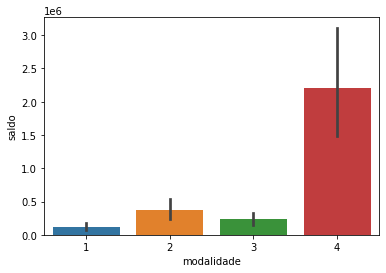

In [275]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(x="modalidade", y="saldo", data=agg[(agg.nivel_risco != 'HH') & (agg.ref==n)])

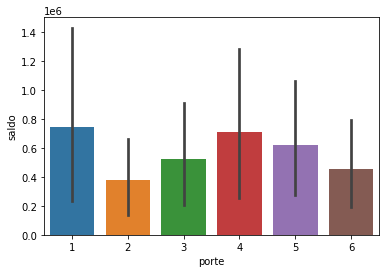

In [276]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(x="porte", y="saldo", data=agg[(agg.nivel_risco != 'HH') & (agg.ref==n)])